In [13]:
!pip install opencv-python torch torchvision onnx onnxruntime onnxscript matplotlib

In [14]:
import urllib.request
import os

# Download deploy.prototxt
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
    "deploy.prototxt"
)

# Download caffemodel
urllib.request.urlretrieve(
    "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
    "res10_300x300_ssd_iter_140000.caffemodel"
)

print("Downloaded:", os.listdir("."))

Downloaded: ['.anaconda', '.cache', '.conda', '.continuum', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.local', '.matplotlib', '.streamlit', '.vscode', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'deploy.prototxt', 'Documents', 'Downloads', 'face_detector.onnx', 'face_detector.onnx.data', 'Favorites', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{ced4e932-0419-11f1-94a8-c873bbac87d1}.TM.blf', 'NTUSER.DAT{ced4e932-0419-11f1-94a8-c873bbac87d1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{ced4e932-0419-11f1-94a8-c873bbac87d1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'res10_300x300_ssd_iter_140000.caffemodel', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Videos']


In [15]:
import os

print("Current directory:", os.getcwd())
print("Files here:", os.listdir("."))

Current directory: C:\Users\User
Files here: ['.anaconda', '.cache', '.conda', '.continuum', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.local', '.matplotlib', '.streamlit', '.vscode', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'deploy.prototxt', 'Documents', 'Downloads', 'face_detector.onnx', 'face_detector.onnx.data', 'Favorites', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{ced4e932-0419-11f1-94a8-c873bbac87d1}.TM.blf', 'NTUSER.DAT{ced4e932-0419-11f1-94a8-c873bbac87d1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{ced4e932-0419-11f1-94a8-c873bbac87d1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'res10_300x300_ssd_iter_140000.caffemodel', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Videos']


Inference latency: 70.1 ms


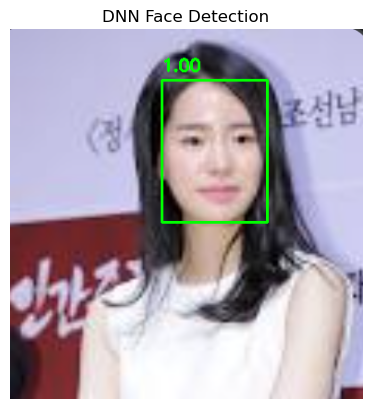

In [16]:
import cv2
import matplotlib.pyplot as plt
import time

net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10_300x300_ssd_iter_140000.caffemodel")

img = cv2.imread("Downloads/Gambar Aktris.png")
h, w = img.shape[:2]
blob = cv2.dnn.blobFromImage(img, 1.0, (300, 300), (104.0, 177.0, 123.0))

start = time.time()
net.setInput(blob)
detections = net.forward()
latency = (time.time() - start) * 1000  # ms

for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]
    if confidence > 0.5:
        box = detections[0, 0, i, 3:7] * [w, h, w, h]
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"{confidence:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

print(f"Inference latency: {latency:.1f} ms")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("DNN Face Detection")
plt.axis("off")
plt.show()

In [18]:
import torch
import torchvision
import os

model = torchvision.models.mobilenet_v2(weights=torchvision.models.MobileNet_V2_Weights.DEFAULT)
model.eval()

dummy_input = torch.randn(1, 3, 300, 300)

torch.onnx.export(
    model,
    dummy_input,
    "face_detector.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=18,
    dynamo=False  # use legacy exporter — avoids the .data file issue on Windows
)

print("Exported to face_detector.onnx")
print(f"Model size: {os.path.getsize('face_detector.onnx') / 1e6:.1f} MB")

C:\Users\User\AppData\Local\Temp\ipykernel_25268\1644768759.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Exported to face_detector.onnx
Model size: 14.0 MB


In [19]:
import onnxruntime as ort
import numpy as np
import os

session = ort.InferenceSession("face_detector.onnx")
input_name = session.get_inputs()[0].name

dummy = np.random.randn(1, 3, 300, 300).astype(np.float32)

start = time.time()
output = session.run(None, {input_name: dummy})
latency = (time.time() - start) * 1000

print(f"ONNX Runtime inference latency: {latency:.1f} ms")
print(f"Output shape: {output[0].shape}")

ONNX Runtime inference latency: 51.2 ms
Output shape: (1, 1000)


In [20]:
import cv2
import time
import csv
from datetime import datetime

net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10_300x300_ssd_iter_140000.caffemodel")

cap = cv2.VideoCapture(0)
fps_list = []
log = []

print("Press Q to quit")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w = frame.shape[:2]
    blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0))

    start = time.time()
    net.setInput(blob)
    detections = net.forward()
    fps = 1.0 / (time.time() - start)
    fps_list.append(fps)

    face_count = 0
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > 0.5:
            face_count += 1
            box = detections[0, 0, i, 3:7] * [w, h, w, h]
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"{confidence:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Log timestamp + face count
    log.append({
        "timestamp": datetime.now().strftime("%H:%M:%S"),
        "face_count": face_count,
        "fps": round(fps, 1)
    })

    cv2.putText(frame, f"FPS: {fps:.1f}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f"Faces: {face_count}", (10, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow("Edge Face Detection - ONNX Ready", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# Save log to CSV
with open("face_log.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["timestamp", "face_count", "fps"])
    writer.writeheader()
    writer.writerows(log)

print(f"Average FPS: {sum(fps_list)/len(fps_list):.1f}")
print(f"Log saved to face_log.csv ({len(log)} frames recorded)")

Press Q to quit
Average FPS: 45.9
Log saved to face_log.csv (4396 frames recorded)
